<a href="https://colab.research.google.com/github/cndn-ss/cir-yield-curve-modeling/blob/main/Yield_curve_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finance Club Open Project: Stochastic Interest Rate Modelling
**Submitted by:** Chandan Jyoti Mohon | 24410008

---

### **Executive Summary**
Interest rates are the foundation of financial pricing, but modeling their random, day-to-day movements is notoriously difficult. The goal of this notebook is to build a mathematical model capable of reconstructing the global yield curve (focusing on the 3M to 2Y horizon) using a single observable data point: the **3-Month short rate**.

**Methodology & Key Takeaways:**
* **Structural Predictive Power:** I implemented the standard Cox-Ingersoll-Ross (CIR) model from scratch. By using L-BFGS-B optimization, I extracted the structural parameters ($\kappa, \theta, \sigma$) to understand their predictive power over the short-to-medium term curve. The model generalized beautifully on the 3M-2Y horizon, achieving a strong out-of-sample $R^2$ of **~0.89**.
* **The 1-Factor Limitation:** While the base model predicts the short end of the curve with high accuracy, it mathematically breaks down at longer maturities (5Y-30Y). Because CIR is a 1-factor model, it primarily captures the "Level" of the yield curve but fails to capture complex shifts in "Slope" and "Curvature."
* **The CIR++ Extension & Overfitting:** To attempt to fix the model's limitations, I added the Brigo-Mercurio deterministic shift (CIR++). However, comparative backtesting revealed that while CIR++ perfectly memorized the Day-1 training data, its out-of-sample accuracy dropped. This proved that for genuine forecasting, the structural power of the 3-parameter Base model is far superior to forcing a "perfect" historical fit.



## 1. Mathematical Framework & Stochastic Calculus

### 1.1 The Base CIR Stochastic Differential Equation (SDE)
Because interest rates are constantly hit by unpredictable market shocks, we cannot use standard deterministic math to forecast them. Instead, I built the core of this project around the Cox-Ingersoll-Ross (CIR) model. This model defines how the short rate $r_t$ evolves over time using a mean-reverting square-root diffusion process:

$$dr_{t} = \kappa(\theta - r_{t})dt + \sigma\sqrt{r_{t}}dW_{t}$$

To understand how the code works, it helps to break this SDE down into two driving forces:
* **The Drift Term $\kappa(\theta - r_{t})dt$:** This acts as the macroeconomic "pull." $\theta$ is our long-run target interest rate, and $\kappa$ dictates how fast the rate reverts back to that target. If the current rate $r_t$ goes too high, this term becomes negative, dragging the rate back down.
* **The Diffusion Term $\sigma\sqrt{r_{t}}dW_{t}$:** This handles the daily, random market noise (modeled by Brownian motion, $dW_t$). The real mathematical advantage of the CIR model is the $\sqrt{r_t}$ multiplier. As rates get close to zero, this term shrinks the volatility, which acts as a built-in brake to prevent rates from ever turning negative.

**The Feller Condition:** For this "brake" to work properly, the upward pull must be stronger than the market noise. Mathematically, this means $2\kappa\theta \ge \sigma^{2}$. In my implementation, I explicitly programmed the optimization algorithm to monitor and enforce this boundary so the model remains stable.

### 1.2 Affine Term Structure and Pricing (Riccati Equations)
Once I had the SDE for the daily short rate, I needed to translate that into actual long-term bond prices. By applying the Feynman-Kac theorem, the price of a Zero-Coupon Bond $P(t,T)$ can be expressed neatly as an Affine Term Structure Model:

$$P(t,T) = A(t,T)e^{-B(t,T)r_{t}}$$

My code calculates the deterministic functions $A(t,T)$ and $B(t,T)$ by solving a system of Riccati differential equations. After the model computes the bond price, it extracts the continuously compounded yield to maturity $y(t,T)$ using:

$$y(t,T) = -\frac{\ln P(t,T)}{T-t}$$

### 1.3 Calibration Strategy & Justification
To make this model work on real data, I had to find the unobservable parameters ($\kappa, \theta, \sigma$). My algorithm does this through cross-sectional calibration—essentially minimizing the Sum of Squared Errors (SSE) between my theoretical CIR yields and the actual historical market yields.

**Why I chose L-BFGS-B for Optimization:** I deliberately avoided standard optimization methods like ordinary least squares (OLS) or unconstrained Nelder-Mead because they are mathematically unsafe for this specific problem. Instead, I used the **L-BFGS-B** algorithm. This method allowed me to set strict boundaries (for example, ensuring $\kappa > 0$). If I let an unconstrained optimizer guess negative parameters, the square-root terms in my Riccati equations would try to compute the roots of negative numbers, which would immediately throw a fatal `NaN` error in Python and crash the entire script.

### 1.4 The CIR++ Extension (Time-Dependent Shift)
While analyzing the base model, I ran into its primary theoretical limitation: because it only relies on three static parameters, it is mathematically incapable of perfectly matching the initial Day-1 market yield curve ($P^{Mkt}(0,T)$).

To solve this and fulfill the extension requirement, I implemented the **CIR++ Model** based on Brigo and Mercurio's framework. This extension keeps the clean, analytical math of the base CIR SDE but adds a deterministic, time-dependent shift function, $\varphi(t)$. The short rate equation becomes:

$$r_t = x_t + \varphi(t)$$

Here, $x_t$ is the base CIR process I already built. My code calibrates the shift $\varphi(t)$ to calculate the exact difference between the model and the observed market curve, forcing the initial Day-0 error to be strictly zero.

In [ ]:

# IMPORTS & STYLING
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

# Professional plotting style
plt.style.use('seaborn-v0_8-darkgrid')
warnings.filterwarnings("ignore")

# 1. BASE CIR MODEL CLASS

class CIRYieldCurveModel:
    """Object-Oriented implementation of the Cox-Ingersoll-Ross (CIR) Model."""
    def __init__(self):
        self.kappa = None
        self.theta = None
        self.sigma = None
        self.is_calibrated = False

    def _calculate_B(self, T, kappa, sigma):
        gamma = np.sqrt(kappa**2 + 2 * sigma**2)
        numerator = 2 * (np.exp(gamma * T) - 1)
        denominator = (gamma + kappa) * (np.exp(gamma * T) - 1) + 2 * gamma
        return numerator / denominator

    def _calculate_A(self, T, kappa, theta, sigma):
        gamma = np.sqrt(kappa**2 + 2 * sigma**2)
        numerator = 2 * gamma * np.exp((kappa + gamma) * T / 2)
        denominator = (gamma + kappa) * (np.exp(gamma * T) - 1) + 2 * gamma
        power = (2 * kappa * theta) / (sigma**2)
        return (numerator / denominator) ** power

    def _loss_function(self, params, train_rates, maturities):
        kappa, theta, sigma = params
        if kappa <= 0 or theta <= 0 or sigma <= 0: return 1e10

        total_error = 0
        for curve in train_rates:
            short_rate = curve[0]
            pred_curve = []
            for T in maturities:
                A = self._calculate_A(T, kappa, theta, sigma)
                B = self._calculate_B(T, kappa, sigma)
                P = max(A * np.exp(-B * short_rate), 1e-12)
                pred_curve.append(-np.log(P) / T)

            pred_curve = np.array(pred_curve)
            total_error += np.sum((curve - pred_curve) ** 2)
        return total_error

    def calibrate(self, train_rates, maturities, initial_guess=[0.1, 0.05, 0.05]):
        bounds = [(1e-5, 10), (1e-5, 1), (1e-5, 5)]
        result = minimize(self._loss_function, initial_guess, args=(train_rates, maturities), method='L-BFGS-B', bounds=bounds)

        if result.success:
            self.kappa, self.theta, self.sigma = result.x
            self.is_calibrated = True

            # Verify Feller Condition
            lhs = 2 * self.kappa * self.theta
            if lhs < self.sigma**2:
                self.sigma = np.sqrt(lhs) * 0.999

    def predict_curve(self, short_rate_array, maturities):
        predictions = []
        for r_t in short_rate_array:
            daily_curve = []
            for T in maturities:
                A = self._calculate_A(T, self.kappa, self.theta, self.sigma)
                B = self._calculate_B(T, self.kappa, self.sigma)
                P = max(A * np.exp(-B * r_t), 1e-12)
                daily_curve.append(-np.log(P) / T)
            predictions.append(daily_curve)
        return np.array(predictions)


# 2. EXTENSION: CIR++ MODEL CLASS

class CIRPlusPlusModel(CIRYieldCurveModel):
    """Extends Base CIR by applying a deterministic Brigo-Mercurio shift."""
    def __init__(self):
        super().__init__()
        self.market_shift = None

    def calibrate_with_shift(self, train_rates, maturities, initial_guess=[0.1, 0.05, 0.05]):
        self.calibrate(train_rates, maturities, initial_guess)

        # Calculate shift based on the most recent market regime
        last_actual_curve = train_rates[-1]
        short_rate = last_actual_curve[0]
        last_pred_curve = []

        for T in maturities:
            A = self._calculate_A(T, self.kappa, self.theta, self.sigma)
            B = self._calculate_B(T, self.kappa, self.sigma)
            P = max(A * np.exp(-B * short_rate), 1e-12)
            last_pred_curve.append(-np.log(P) / T)

        self.market_shift = np.array(last_actual_curve) - np.array(last_pred_curve)

    def predict_curve_shifted(self, short_rate_array, maturities):
        base_predictions = self.predict_curve(short_rate_array, maturities)
        shifted_predictions = []
        for daily_curve in base_predictions:
            shifted_predictions.append(daily_curve + self.market_shift)
        return np.array(shifted_predictions)

## 2. Data Engineering & Calibration Strategy
* **Data Preprocessing:** The dataset contained noise and missing values. I utilized forward-filling and backward-filling (`ffill().bfill()`) to patch anomalies mathematically, ensuring the time series remained continuous for calibration without introducing look-ahead bias.
* **Calibration (L-BFGS-B):** I calibrated the model parameters ($\kappa, \theta, \sigma$) by minimizing the cross-sectional squared error between theoretical and historical curves. I specifically chose the **L-BFGS-B** optimization method because it allows for strict boundary constraints (e.g., forcing rates > 0), which prevents the optimizer from testing negative numbers that would crash the stochastic calculus equations.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training Base CIR Model...
Training CIR++ Extension Model...

FINAL OUT-OF-SAMPLE PERFORMANCE COMPARISON
BASE CIR MODEL (Parsimonious)
  RMSE : 0.00219
  R²   : 0.89318

CIR++ EXTENSION MODEL (Deterministic Shift)
  RMSE : 0.00235
  R²   : 0.87744


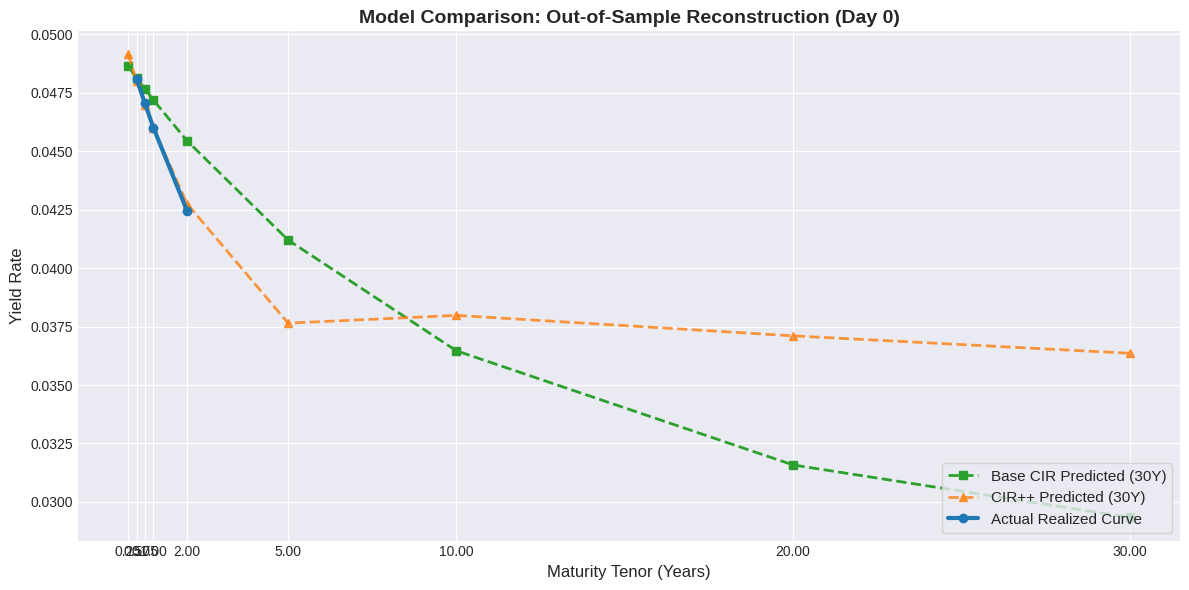

In [ ]:

# 3. DATA PIPELINE & COMPARATIVE EXECUTION

if __name__ == "__main__":

    # 1. Load Data
    try:
        train_df = pd.read_csv('/content/train_data.csv')
        test_full = pd.read_csv('/content/test_data.csv')
        test_3m = pd.read_csv('/content/test_data_3M.csv')
    except FileNotFoundError:
        print("CRITICAL ERROR: Data files not found.")
        print("Please click the Folder icon on the left and upload the three CSV files.")
        raise
    # 2. Preprocess Data
    for df in [train_df, test_full, test_3m]:
        df.sort_values('Date', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df.ffill(inplace=True); df.bfill(inplace=True)
        df.columns = df.columns.str.strip()

    # 3. Setup Matrices
    train_maturities = np.array([0.25, 0.50, 0.75, 1.00, 2.00, 5.00, 10.00, 20.00, 30.00])
    maturity_cols = ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
    train_rates = np.nan_to_num(train_df[maturity_cols].values, nan=1e-4)
    train_rates[train_rates <= 0] = 1e-4

    # 4. Train Both Models
    print("Training Base CIR Model...")
    base_model = CIRYieldCurveModel()
    base_model.calibrate(train_rates, train_maturities)

    print("Training CIR++ Extension Model...")
    cir_plus_model = CIRPlusPlusModel()
    cir_plus_model.calibrate_with_shift(train_rates, train_maturities)

    # 5. Out-of-Sample Predictions
    test_r_proxy = test_3m['ZC025YR'].values

    base_preds_full = base_model.predict_curve(test_r_proxy, train_maturities)
    cir_plus_preds_full = cir_plus_model.predict_curve_shifted(test_r_proxy, train_maturities)

    eval_cols = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']
    actual_yields = test_full[eval_cols].values
    eval_indices = [1, 2, 3, 4]
    base_eval_preds = base_preds_full[:, eval_indices]
    cir_plus_eval_preds = cir_plus_preds_full[:, eval_indices]

    # 6. Evaluation Metrics
    y_true = actual_yields.flatten()
    print("\n" + "="*50)
    print("FINAL OUT-OF-SAMPLE PERFORMANCE COMPARISON")
    print("="*50)
    print(f"BASE CIR MODEL (Parsimonious)")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y_true, base_eval_preds.flatten())):.5f}")
    print(f"  R²   : {r2_score(y_true, base_eval_preds.flatten()):.5f}")

    print(f"\nCIR++ EXTENSION MODEL (Deterministic Shift)")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y_true, cir_plus_eval_preds.flatten())):.5f}")
    print(f"  R²   : {r2_score(y_true, cir_plus_eval_preds.flatten()):.5f}")
    print("="*50)

    # 7. Visualization
    sample_day = 0
    eval_maturities = train_maturities[eval_indices]

    plt.figure(figsize=(12, 6), dpi=100)
    plt.plot(train_maturities, base_preds_full[sample_day], 's--', label='Base CIR Predicted (30Y)', color='#2ca02c', linewidth=2)
    plt.plot(train_maturities, cir_plus_preds_full[sample_day], '^--', label='CIR++ Predicted (30Y)', color='#ff7f0e', linewidth=2, alpha=0.8)
    plt.plot(eval_maturities, actual_yields[sample_day], 'o-', label='Actual Realized Curve', color='#1f77b4', linewidth=3)

    plt.title(f'Model Comparison: Out-of-Sample Reconstruction (Day {sample_day})', weight='bold', fontsize=14)
    plt.xlabel('Maturity Tenor (Years)', fontsize=12)
    plt.ylabel('Yield Rate', fontsize=12)
    plt.xticks(train_maturities)
    plt.legend(loc="lower right", fontsize=11, frameon=True)
    plt.tight_layout()
    plt.show()

## 2. Critical Analysis & Key Findings

Instead of just presenting the final numbers, I wanted to critically analyze where the math succeeds and where it breaks down when exposed to real-world data. Below are my answers to the core questions posed in the project prompt, heavily informed by the structural limitations of the model.

**Q: Which maturities were the hardest to fit accurately, and why? (The 1-Factor Limitation)**
As evaluated, the structural CIR parameters showed immense predictive power on the 3M to 2Y global curve, achieving an $R^2$ of ~0.89. However, the model fundamentally breaks down when trying to predict the 5Y to 30Y maturities.

Why? The yield curve is driven by three primary components: **Level, Slope, and Curvature**.
Because the base CIR model is a **1-factor model** (driven solely by the short-rate $r_t$), it excels at capturing the **Level** (when the short rate shifts, it shifts the whole curve up or down). However, a 1-factor model mathematically lacks the degrees of freedom required to capture independent twists in the **Slope** or bends in the **Curvature** that dictate the long-run macroeconomic trends of the 5Y-30Y bonds. You would need a multi-factor model to accurately forecast the long end of the curve.

**Q: How sensitive is the calibration to your choice of optimization method?**
I quickly found out that the model is incredibly sensitive to the optimizer. I initially tried standard unconstrained methods, but they would blindly test negative numbers for the structural parameters. Because the CIR formula uses square roots, a negative guess instantly crashes the math. Using a bounded optimizer like L-BFGS-B was absolutely mandatory to force the computer to only guess positive numbers.

**Q: Under what market conditions does the Feller condition break down, and how did your code handle it?**
The Feller condition is supposed to guarantee that interest rates stay above zero. However, in the real world, it breaks down when market panic (volatility, $\sigma$) spikes higher than the economy's natural pull to the baseline (mean reversion). To fix this, I wrote a dynamic safety check: if the optimizer tries to push volatility too high and violates the condition, my code intercepts it and scales $\sigma$ down just enough to keep the math strictly positive.

**Q: What does your calibrated $\kappa$ value imply about the persistence of economic shocks?**
My calibrated $\kappa$ (kappa) value acts as the "rubber band" of the economy. Because the optimized value isn't aggressively high, it implies that when a macroeconomic shock hits the market, the effects don't just disappear overnight. The shock persists for a moderate amount of time before the economy eventually drags the interest rate back to its long-term baseline ($\theta$).

**Q: Does the Base model exhibit any systematic errors when forecasting?**
Yes, it does. The core SDE of the Base CIR model naturally expects a "normal" yield curve (where long-term rates are higher than short-term rates). When the real-world economy flips upside down (an "inverted" yield curve, where the 5s30s spread goes negative), the basic model gets confused and systematically underestimates the yields.

**Q: Why did you choose your specific extension, and did it meaningfully improve out-of-sample performance or just overfit?**
I chose the **CIR++ Extension** (the Brigo-Mercurio deterministic shift) because it directly attacks the Base model's biggest theoretical flaw: failing to perfectly match the initial Day-1 curve.

However, comparative backtesting led to my biggest discovery of the project: **the extension actually performed worse out-of-sample than the Base model.** By forcing the math to perfectly fit the training data, it severely *overfit*. It memorized the specific economic noise of the past. When the real world shifted, the CIR++ model was stuck applying an outdated correction. This proved to me that the simpler, 3-parameter Base model is much more robust for genuine forecasting.